**HOUSING dataset - work in progress**

Practicing Python coding skills for Data Analysis. Will unearth trends from the data in the Housing.csv file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
housing = pd.read_csv(r'C:\Users\rober\Documents\Data Science\GitHub\DIY projects\Datasets\Housing.csv')

In [ ]:
housing.info() #checking columns and number of entries

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
housing.duplicated().sum() #checking for duplicates

np.int64(0)

In [ ]:
housing.describe().T #checking statistical summary of numerical columns

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


In [33]:
name_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea', 'furnishingstatus']
# ^ categorical columns

for col in name_cols:
    print(housing[col].value_counts())
    print('--' *5)

mainroad
yes    468
no      77
Name: count, dtype: int64
----------
guestroom
no     448
yes     97
Name: count, dtype: int64
----------
basement
no     354
yes    191
Name: count, dtype: int64
----------
hotwaterheating
no     520
yes     25
Name: count, dtype: int64
----------
airconditioning
no     373
yes    172
Name: count, dtype: int64
----------
prefarea
no     417
yes    128
Name: count, dtype: int64
----------
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64
----------


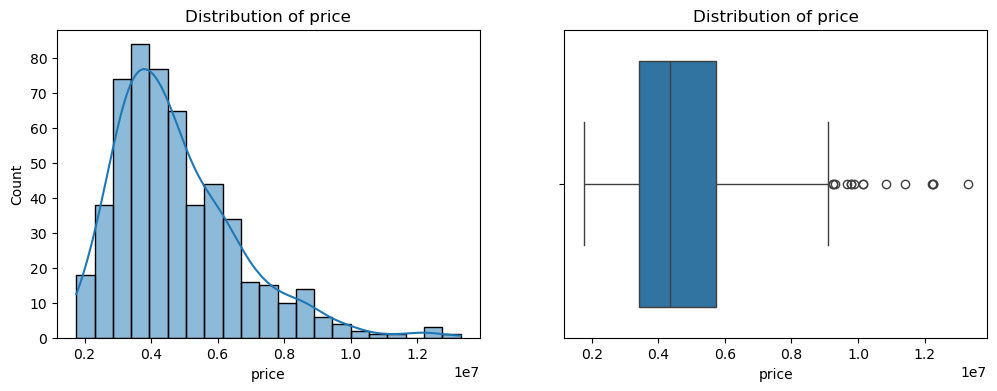

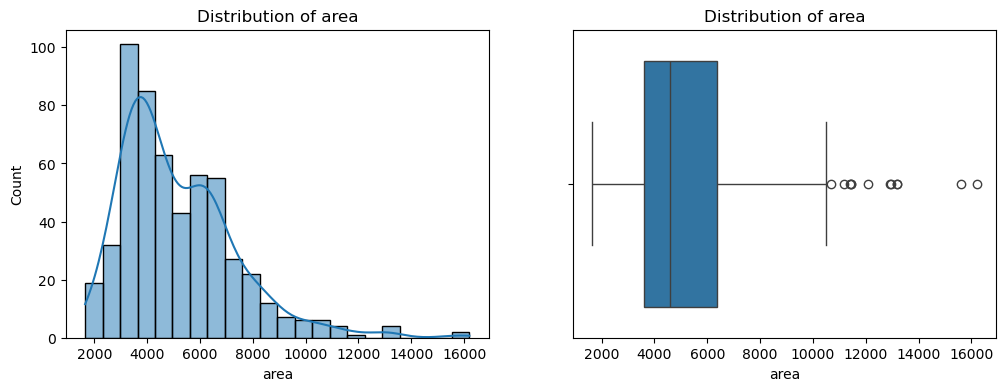

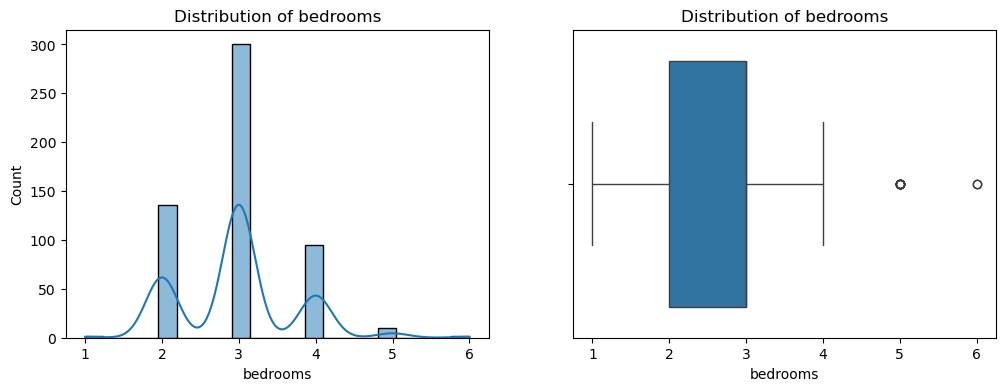

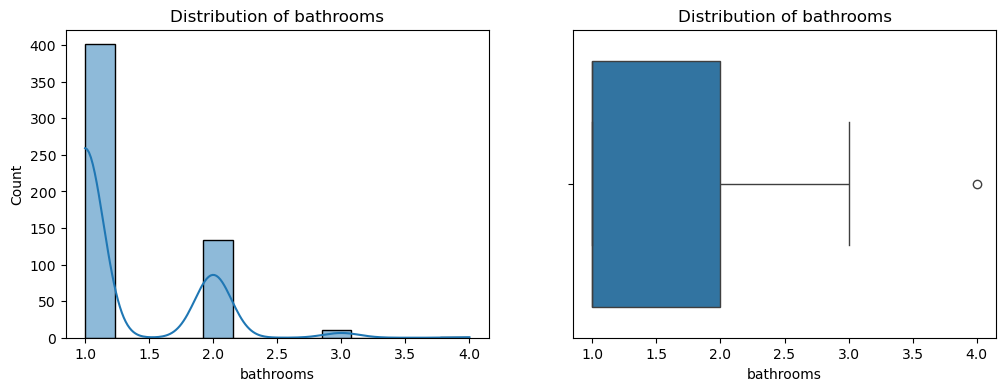

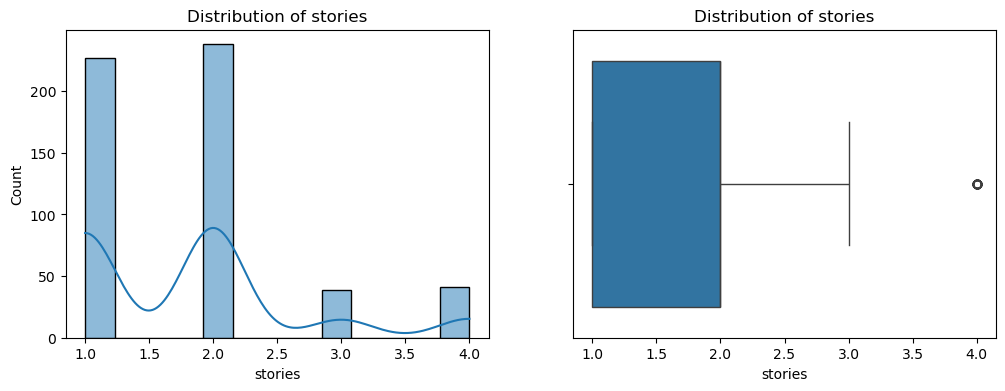

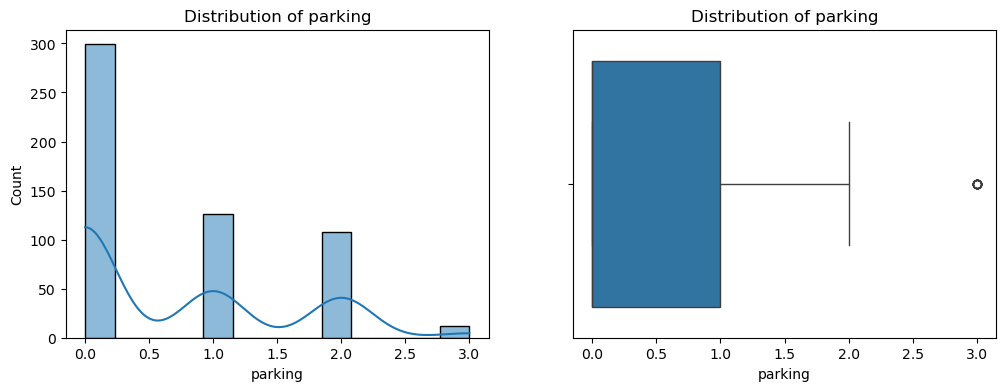

In [31]:
import seaborn as sns
for col in housing.select_dtypes(include=['int64']).columns:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.histplot(housing[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.subplot(1,2,2)
    sns.boxplot(x=housing[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.show()

**OBERSERVATIONS**

Average price of a home is $4.7 million.

Average area is 5200 square feet.

Most homes have 3 bedrooms; 1 bathroom; are 1-2 stories; and no reserved parking spaces.

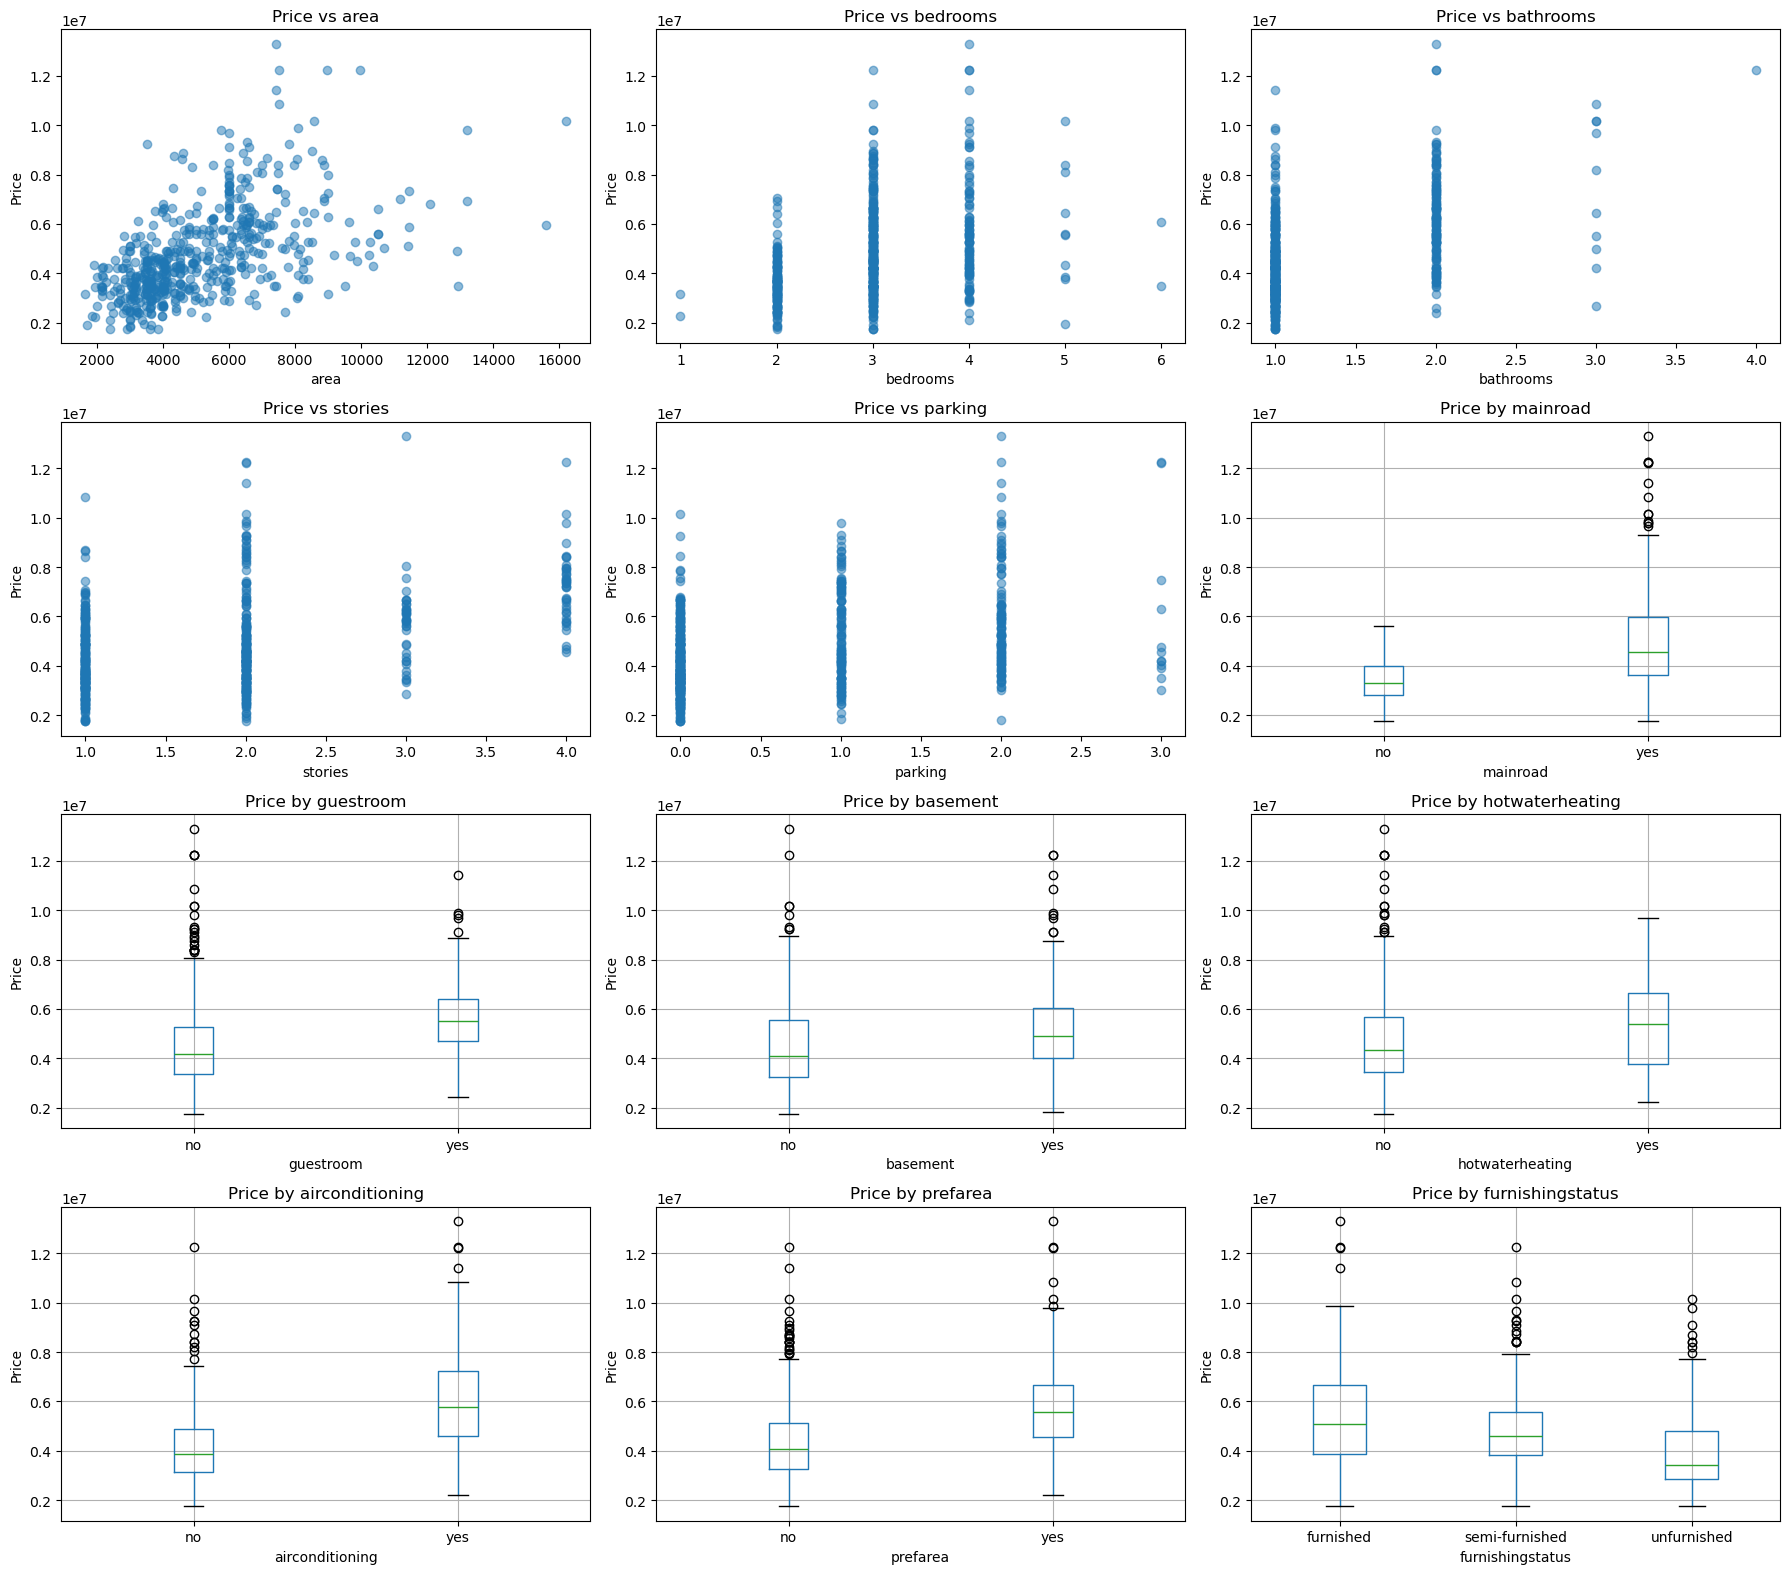

In [ ]:
# Create a comprehensive visualization showing how price is affected by all other columns
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle('Price Distribution Across All Features', fontsize=16, y=0.995)

# Numerical columns vs price
numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
for idx, col in enumerate(numerical_cols):
    row, col_idx = idx // 3, idx % 3 # Adjusted for 0-based index
    axes[row, col_idx].scatter(housing[col], housing['price'], alpha=0.5)
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Price')
    axes[row, col_idx].set_title(f'Price vs {col}')

# Categorical columns vs price
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
for idx, col in enumerate(categorical_cols):
    position = idx + len(numerical_cols)
    row, col_idx = position // 3, position % 3 # Adjusted for 0-based index
    housing.boxplot(column='price', by=col, ax=axes[row, col_idx])
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Price')
    axes[row, col_idx].set_title(f'Price by {col}')
    axes[row, col_idx].get_figure().suptitle('')

plt.tight_layout()
plt.show()

**OBSERVATIONS**

The price of houses are usually higher due to:

The presence of A/C

Number of stories (the cheapest 4-story house starts at $4 million).

The presence of a guestroom

Being a 4-bedroom house. It has a wider distribution of prices, and the cheapest 4-bedroom is more expensive than the cheapest of all but 6-bedroom houses

The presence of a basement

Furnished houses

The home being located near a main road


**Other observations**

1- and 2-story houses have a wider distribution of prices.

Hot water heating is not a good indicator of the price of a home, as a good number of homes without hot water heating are higher in price than the most expensive homes that do have it.
